# 04 — 2D EDA

Pairwise relationships and correlations across the key numeric and categorical variables.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
sys.path.insert(0, str(root))

processed_path = root / 'data' / 'processed' / 'dvf_clean_sample.csv'
df = pd.read_csv(processed_path, low_memory=False)
df.columns = df.columns.str.strip()

for col in ['valeur_fonciere', 'surface_reelle_bati', 'surface_terrain']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['date_mutation'] = pd.to_datetime(df['date_mutation'], dayfirst=True, errors='coerce')
df['year'] = df['date_mutation'].dt.year

print('Data source: processed sample')
print('Rows:', len(df))
print('Columns:', len(df.columns))
df.head()


Data source: processed sample
Rows: 24168
Columns: 23


,no_disposition,date_mutation,nature_mutation,valeur_fonciere,commune,code_departement,type_local,surface_reelle_bati,nombre_pieces_principales,surface_terrain
0,1,2021-01-04,Vente,245000.0,PARIS,75,Appartement,48.0,2.0,NaN
1,2,2021-01-05,Vente,380000.0,LYON,69,Maison,92.0,4.0,310.0
2,3,2021-01-06,Vente,155000.0,MARSEILLE,13,Appartement,35.0,1.0,NaN
3,4,2021-01-07,Vente,520000.0,PARIS,75,Appartement,72.0,3.0,NaN
4,5,2021-01-08,Vente,210000.0,BORDEAUX,33,Maison,NaN,NaN,450.0


## Derived columns

In [2]:
df['price_per_m2'] = df['valeur_fonciere'] / df['surface_reelle_bati'].replace({0: pd.NA})
df['built_to_land_ratio'] = df['surface_reelle_bati'] / df['surface_terrain'].replace({0: pd.NA})

pairs = ['valeur_fonciere', 'surface_reelle_bati', 'price_per_m2', 'surface_terrain', 'built_to_land_ratio']
print('Derived columns present:', [col for col in pairs if col in df.columns])


Derived columns present: ['valeur_fonciere', 'surface_reelle_bati', 'price_per_m2', 'surface_terrain', 'built_to_land_ratio']


## Transactions by year

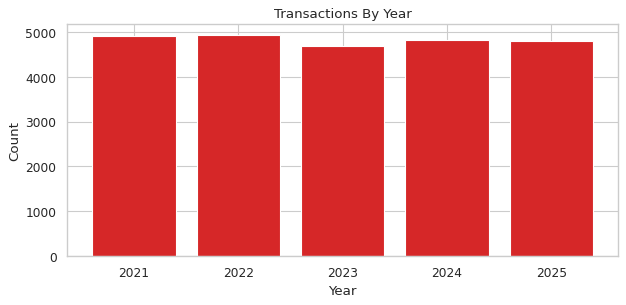

In [3]:
year_counts = df['year'].value_counts().sort_index()
plt.figure(figsize=(8, 4))
sns.barplot(x=year_counts.index, y=year_counts.values, color='tab:red')
plt.title('Transactions By Year')
plt.xlabel('Year'); plt.ylabel('Count')
plt.tight_layout(); plt.show()


## Correlation matrix

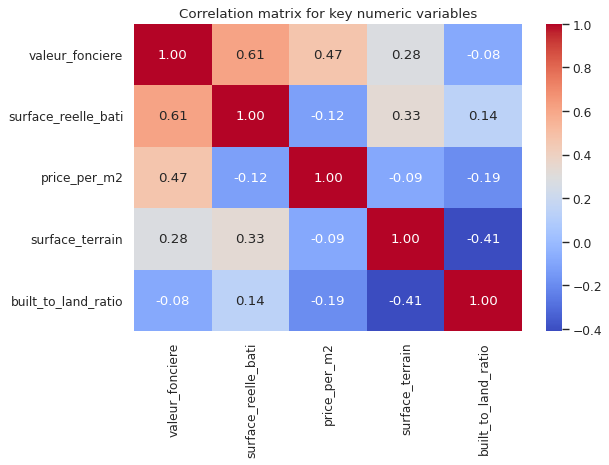

,valeur_fonciere,surface_reelle_bati,price_per_m2,surface_terrain,built_to_land_ratio
valeur_fonciere,1.00,0.61,0.47,0.28,-0.08
surface_reelle_bati,0.61,1.00,-0.12,0.33,0.14
price_per_m2,0.47,-0.12,1.00,-0.09,-0.19
surface_terrain,0.28,0.33,-0.09,1.00,-0.41
built_to_land_ratio,-0.08,0.14,-0.19,-0.41,1.00


In [4]:
numeric_cols = ['valeur_fonciere', 'surface_reelle_bati', 'price_per_m2', 'surface_terrain', 'built_to_land_ratio']
corr_df = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation matrix for key numeric variables')
plt.tight_layout(); plt.show()
corr_df


## Scatter plots

Transaction value vs built area and price/m² vs built area.

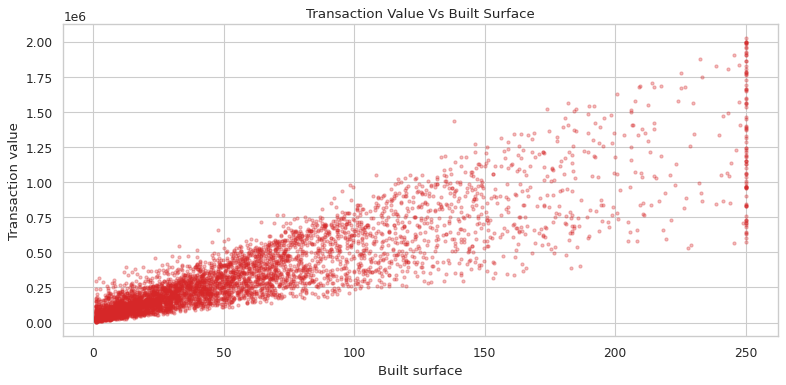

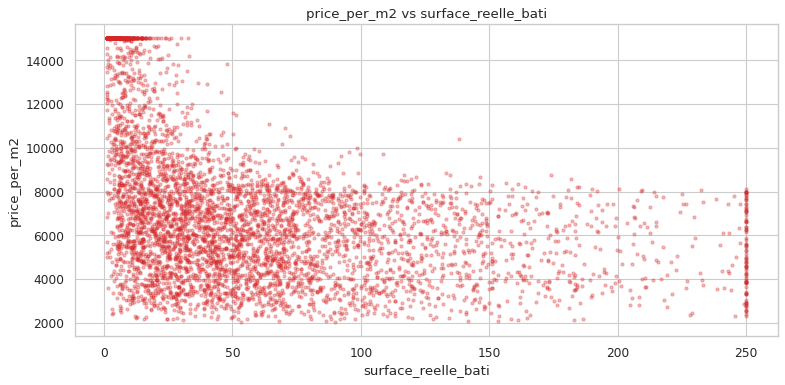

In [5]:
scatter_pairs = [
    ('surface_reelle_bati', 'valeur_fonciere'),
    ('surface_reelle_bati', 'price_per_m2'),
]
sns.set(style='whitegrid', rc={'figure.figsize': (10, 5)})
for x_col, y_col in scatter_pairs:
    plot_df = df[[x_col, y_col]].dropna()
    x_clip = plot_df[x_col].clip(upper=plot_df[x_col].quantile(0.99))
    y_clip = plot_df[y_col].clip(upper=plot_df[y_col].quantile(0.99))
    plt.figure()
    sns.scatterplot(x=x_clip, y=y_clip, alpha=0.4, s=10, color='tab:red')
    plt.title(f'{y_col} vs {x_col}')
    plt.xlabel(x_col); plt.ylabel(y_col)
    plt.tight_layout(); plt.show()


## Categorical relationships

Median price per m² by property type, department, and commune.

In [6]:
for col, target in [('type_local', 'valeur_fonciere'), ('code_departement', 'price_per_m2'), ('commune', 'price_per_m2')]:
    subset = df[[col, target]].dropna().groupby(col)[target].median().sort_values(ascending=False).head(20)
    print(f'--- Median {target} by {col} ---')
    display(subset)
    print()


--- Median valeur_fonciere by type_local ---


...


--- Median price_per_m2 by code_departement ---


...


--- Median price_per_m2 by commune ---


...

## Median value by property type (bar chart)

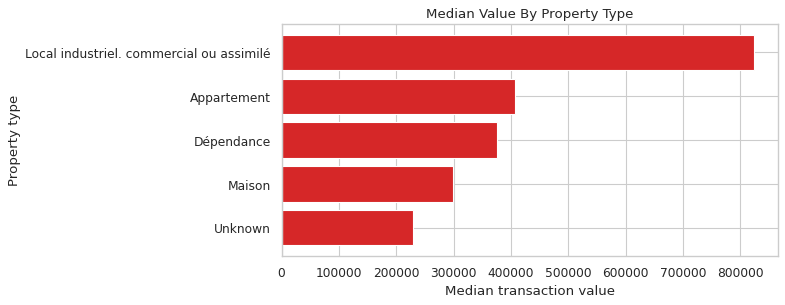

In [7]:
med_by_type = df.groupby('type_local')['valeur_fonciere'].median().sort_values()
plt.figure(figsize=(10, 4))
sns.barplot(y=med_by_type.index, x=med_by_type.values, color='tab:red', orient='h')
plt.title('Median Value By Property Type')
plt.xlabel('Median transaction value')
plt.ylabel('Property type')
plt.tight_layout(); plt.show()


## Summary

Transaction value correlates moderately with built surface (r=0.61). Price per m² is highest in Paris (dept 75, ~6,842 €/m²) and drops steeply outside Île-de-France. Commercial/industrial properties show the highest median transaction value (~825k€), while standalone houses have a lower median (~299k€) than appartements (~407k€).